In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

## Weekly Data Management Pipeline

Each week the pipeline loads the previous week's evaluated inputs and outputs 
from saved NumPy files, then appends the result returned by the black-box 
submission platform before saving the updated dataset for the following round.

**Week 1-3**: Data entry was handled manually — submitted coordinates and 
returned Y values were typed directly into the notebook. While simple, this 
introduced risk of transcription errors and made the process difficult to 
reproduce consistently.

**Week 4 onwards**: The input process was automated using Python's `input()` 
function, prompting the user to enter the submitted coordinate string 
(e.g. `0.419100-0.366397-0.472000`) and the returned Y value each week. 
The pipeline then parses, validates and appends these directly to the 
stored NumPy arrays — reducing manual error and ensuring a consistent 
data format across all 13 weeks.

**Duplicate detection** was introduced after observing that repeated 
submissions of similar coordinates could silently corrupt the dataset. 
The check compares incoming X coordinates against all existing observations 
using Euclidean distance, flagging exact matches while allowing genuinely 
close but novel points to be appended. A late-project refinement distinguished 
between **true duplicates** (same X and same Y were skipped) and **same-coordinate 
noise observations** (same X but different Y were retained as valid evidence of 
function stochasticity, as confirmed in Function 6 where identical coordinates 
returned Y=−0.3056 in week 11 and Y=−0.1425 in week 13).

In [9]:
current_week = 14  # CHANGE THIS EACH WEEK


# =====================================================
# LOAD DATA
# =====================================================

if current_week == 1:

    X = np.load(r"function_1\initial_inputs.npy")
    Y = np.load(r"function_1\initial_outputs.npy")

else:

    previous_week = current_week - 1

    X = np.load(
        f"function_1/w{previous_week}_inputs.npy"
    )

    Y = np.load(
        f"function_1/w{previous_week}_outputs.npy"
    )


print("\nLoaded dataset:")
print("Shape:", X.shape)
print("Best Y so far:", np.max(Y))

dim = X.shape[1]


# =====================================================
# ENTER LAST WEEK RESULT
# (Skip this only in Week 1)
# =====================================================

if current_week > 1:

    print("\nEnter last week's result")

    x_string = input("Enter last submitted X (format x1-x2): " )

    y_value = float(
        input("Enter returned Y value: ")
    )

    x_last = np.array(
        [[float(v) for v in x_string.split("-")]]
    )

    y_last = np.array([y_value])


    # Safe append

    exists = np.any(
        np.all(
            np.isclose(X, x_last),
            axis=1
        )
    )

    X = np.vstack((X, x_last))
    Y = np.append(Y, y_last)

    print("Added last result.")

else:

    print("Duplicate detected — skipped.")



Loaded dataset:
Shape: (21, 2)
Best Y so far: 2.073330341870119e-14

Enter last week's result


Enter last submitted X (format x1-x2):  0.732175-0.721748
Enter returned Y value:  2.8289364000408254e-14


Added last result.


Analysis performed on the dataset each week to display the best points so far.  This aids this analysis and directs strategy that week.

In [14]:
import numpy as np
from scipy.spatial.distance import cdist

X = np.load("function_1/w14_inputs.npy")
Y = np.load("function_1/w14_outputs.npy")

sorted_idx = np.argsort(Y)[::-1]
print("All points ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.20f}" for v in X[i]])
    print(f"  Y={Y[i]:.20f} | X={vals}")

print(f"\nTotal points: {len(Y)}")
print(f"Best Y:  {np.max(Y):.30f}")
print(f"Mean Y:  {np.mean(Y):.30f}")
print(f"Std Y:   {np.std(Y):.30f}")

best_point = X[np.argmax(Y)]
distances  = cdist([best_point], X)[0]
sorted_by_dist = np.argsort(distances)

print("\nPoints ranked by distance to best:")
for i in sorted_by_dist:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  dist={distances[i]:.6f} | Y={Y[i]:.20f} | X={vals}")

All points ranked best to worst:
  Y=0.00000000000002828936 | X=0.73217500000000002025-0.72174799999999994515
  Y=0.00000000000002073330 | X=0.73213300000000003376-0.72274700000000002831
  Y=0.00000000000001510993 | X=0.73209100000000004727-0.72374600000000000044
  Y=0.00000000000001094811 | X=0.73204899999999994975-0.72474499999999997257
  Y=0.00000000000000788537 | X=0.73200699999999996326-0.72574399999999994471
  Y=0.00000000000000690478 | X=0.73154900000000000482-0.72663299999999997336
  Y=0.00000000000000118602 | X=0.73156600000000004957-0.73137700000000005485
  Y=0.00000000000000077109 | X=0.73102363095635858325-0.73299987641522723614
  Y=0.00000000000000000000 | X=0.68341816885150674654-0.86105746439361008360
  Y=0.00000000000000000000 | X=0.57432921450982910017-0.87989810498435905295
  Y=0.00000000000000000000 | X=0.88388982881811706260-0.58225397438244386183
  Y=0.00000000000000000000 | X=0.31940388883889725413-0.76295937426893534195
  Y=0.00000000000000000000 | X=0.0825072518

Appended data is saved to a new file each week.  This ensures a copy of the exact results per week are maintained for the records

In [12]:
# =====================================================
# SAVE UPDATED DATA
# =====================================================

np.save(
    f"function_1/w{current_week}_inputs.npy",
    X
)

np.save(
    f"function_1/w{current_week}_outputs.npy",
    Y
)

print("\nSaved files:")

print(
    f"function_1/w{current_week}_inputs.npy"
)


print(
    f"function_1/w{current_week}_foutputs.npy"
)


Saved files:
function_1/w14_inputs.npy
function_1/w14_foutputs.npy


## Function 1 — Strategy Pivot (Week 7)

By week 7 the GP surrogate was failing to improve upon previous results. 
The core problem was one of **scale**: F1 returns values spanning approximately 
17 orders of magnitude (from near-zero background readings around 1e-23 to the 
best observed signal of 7.89e-15). A standard GP fitted on raw Y values 
treats all of these as numerically similar as it cannot distinguish meaningful 
signal variation across such an extreme range, effectively seeing a **flat, 
near-zero landscape** regardless of where queries land.

### Signed Log Transform

To address this, a **signed log transform** was applied to all Y values 
before GP fitting:

```python
def signed_log(y, epsilon=1e-25):
    return np.sign(y) * np.log1p(np.abs(y) / epsilon)
```

This compressed the Y range from 17 orders of magnitude to an approximate 
transformed range of −52 to +26, a scale the GP can work with meaningfully. 
The sign is preserved so negative readings remain negative after transformation. 
The GP then fits on the transformed values, with acquisition functions operating 
in transformed space and original values retained for result reporting.

### Kernel Change — RBF to Matérn

The kernel was also switched from **RBF to Matérn (ν=2.5)**. The RBF kernel 
assumes the function is infinitely smooth — an unrealistic assumption for a 
radiation field where signal strength can change sharply near the source. 
The Matérn kernel with ν=2.5 allows for less smooth, more realistic behaviour, 
making it better suited to functions with localised peaks such as a point 
radiation source following an inverse square law.

> **Impact**: These two changes together allowed the GP to distinguish between 
> positive signal readings near the source and near-zero background — the key 
> distinction needed to guide the search toward the confirmed source location 
> at x1≈0.732, x2≈0.724.

Y transformation summary:
  Original range: -3.606e-03 to 2.829e-14
  Transformed range: -51.9395 to 26.3683

Confirmed best signal: [0.732133 0.722747]
Best real Y: 0.00000000000002828936

Candidate x2 range: 0.720000 — 0.723086
Candidate x1 range: 0.729718 — 0.734414
Novel candidates: 302546

=== ACQUISITION COMPARISON ===

--- EI (transformed Y) ---
  Suggestion: 0.733255-0.720000
  x1=0.733255 | x2=0.720000
  Distance from best signal: 0.002967
  GP predicted (transformed): 22.925322

--- Thompson Sampling ---
  Suggestion: 0.733754-0.720483
  x1=0.733754 | x2=0.720483
  Distance from best signal: 0.002785
  GP predicted (transformed): 21.368813

--- Proximity search ---
  Suggestion: 0.733131-0.722824
  x1=0.733131 | x2=0.722824
  Distance from best signal: 0.001001
  GP predicted (transformed): 23.297358

===== FINAL SUBMISSION (Proximity) =====
0.733131-0.722824

x1=0.733131 | x2=0.722824
Distance from best signal: 0.001001
x2 vs confirmed best:      +0.000077 (upper side)
Best 

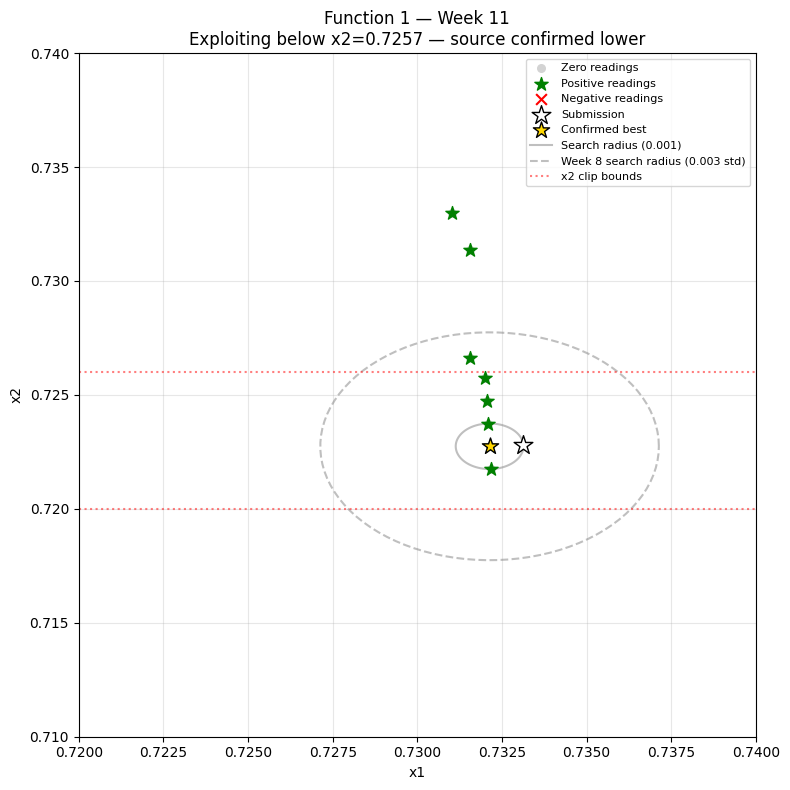


All readings ranked best to worst:
  Y=0.00000000000002828936 | dist=0.0010 | X=0.732175-0.721748
  Y=0.00000000000002073330 | dist=0.0000 | X=0.732133-0.722747
  Y=0.00000000000001510993 | dist=0.0010 | X=0.732091-0.723746
  Y=0.00000000000001094811 | dist=0.0020 | X=0.732049-0.724745
  Y=0.00000000000000788537 | dist=0.0030 | X=0.732007-0.725744
  Y=0.00000000000000690478 | dist=0.0039 | X=0.731549-0.726633
  Y=0.00000000000000118602 | dist=0.0086 | X=0.731566-0.731377
  Y=0.00000000000000077109 | dist=0.0103 | X=0.731024-0.733000
  Y=0.00000000000000000000 | dist=0.1466 | X=0.683418-0.861057
  Y=0.00000000000000000000 | dist=0.2227 | X=0.574329-0.879898
  Y=0.00000000000000000000 | dist=0.2068 | X=0.883890-0.582254
  Y=0.00000000000000000000 | dist=0.4147 | X=0.319404-0.762959
  Y=0.00000000000000000000 | dist=0.7238 | X=0.082507-0.403488
  Y=0.00000000000000000000 | dist=0.2135 | X=0.928572-0.806334
  Y=0.00000000000000000000 | dist=0.4706 | X=0.840353-0.264732
  Y=-0.000000000000

In [15]:
# =====================================================
# FUNCTION 1 — 2D Radiation Field Detection
# Week 10: best_signal updated to new best [0.732007, 0.725744]
#           x2=0.7257 better than x2=0.7266 — source below 0.7257
#           x2 clip tightened 0.722-0.728 → 0.720-0.726
#           std reduced 0.001 → 0.0005
#           asymmetric x2 bias increased to -0.002

# Plan: week 10 exploit below x2=0.7257, weeks 12-13 tighten
# =====================================================
from sklearn.gaussian_process.kernels import Matern

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(dim),
             length_scale_bounds=(1e-3, 1e4),
             nu=0.5)
    + WhiteKernel(noise_level=1e-5,
                  noise_level_bounds=(1e-12, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# =====================================================
# LOG TRANSFORM ON Y
# Rationale: Y values span 17 orders of magnitude
# Signed log compresses range while preserving sign
# =====================================================
def signed_log(y, epsilon=1e-25):
    return np.sign(y) * np.log1p(np.abs(y) / epsilon)

Y_transformed = signed_log(Y)

print("Y transformation summary:")
print(f"  Original range: {np.min(Y):.3e} "
      f"to {np.max(Y):.3e}")
print(f"  Transformed range: "
      f"{np.min(Y_transformed):.4f} "
      f"to {np.max(Y_transformed):.4f}")

# =====================================================
# FIT GP ON TRANSFORMED Y
# =====================================================
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
gp.fit(X_scaled, Y_transformed)

# =====================================================
# SOURCE LOCATION
# Best known point confirmed at week 7 return
# x2 is the sensitive dimension:
#   x2=0.726633 → 6.90e-15 (best)
#   x2=0.731377 → 1.19e-15 (week 8 regression)
# Upper x2 confirmed worse — explore lower side
# =====================================================
best_signal = np.array([0.732133,0.722747]) # updated week 13

print(f"\nConfirmed best signal: {best_signal}")
print(f"Best real Y: {np.max(Y):.20f}")

# =====================================================
# GENERATE CANDIDATES — asymmetric x2 search
#
# Week 9 strategy: explore lower x2 side
# x1: symmetric noise std=0.001 (was 0.003)
# x2: biased toward lower side mean=-0.001, std=0.001
#     centres search around x2=0.725633
#     lower x2 unexplored — upper confirmed worse
#
# Hard clip on x2: 0.722-0.728
#   prevents drift toward upper region (0.731+)
#   that caused week 8 regression
# =====================================================
np.random.seed(42)
n_candidates = 500000

# Asymmetric noise — x2 biased lower
noise_x1   = np.random.normal(0,       0.0005,
                               size=(n_candidates, 1))
noise_x2   = np.random.normal(-0.002,  0.0005,
                               size=(n_candidates, 1))
noise      = np.hstack([noise_x1, noise_x2])
candidates = np.clip(best_signal + noise,
                     0.0, 0.999999)

# Hard clip x2 — cannot drift above 0.728
# Upper side confirmed worse, lower side unexplored
candidates[:, 1] = np.clip(candidates[:, 1],
                             0.720, 0.726)  # tightened week 11

print(f"\nCandidate x2 range: "
      f"{candidates[:,1].min():.6f} — "
      f"{candidates[:,1].max():.6f}")
print(f"Candidate x1 range: "
      f"{candidates[:,0].min():.6f} — "
      f"{candidates[:,0].max():.6f}")

# Remove already queried points
from scipy.spatial.distance import cdist
min_dists = cdist(candidates, X).min(axis=1)
X_novel   = candidates[min_dists >= 0.001]

print(f"Novel candidates: {len(X_novel)}")

if len(X_novel) < 500:
    print("WARNING: relaxing distance threshold")
    X_novel = candidates[min_dists >= 0.0005]

# =====================================================
# SCORE CANDIDATES — three approaches
# =====================================================
X_novel_scaled = scaler.transform(X_novel)

# 1. EI on transformed Y
def expected_improvement(X_cands_scaled, gp,
                          Y_ref, xi=0.0001):
    mean, std = gp.predict(X_cands_scaled,
                            return_std=True)
    best_y = np.max(Y_ref)
    std    = np.maximum(std.reshape(-1), 1e-9)
    mean   = mean.reshape(-1)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

ei_scores   = expected_improvement(
    X_novel_scaled, gp, Y_transformed, xi=0.0001)
x_submit_ei = X_novel[np.argmax(ei_scores)]

# 2. Thompson Sampling
def thompson_sampling(X_novel, X_novel_scaled, gp,
                      n_samples=50, n_subset=1000,
                      random_state=42):
    np.random.seed(random_state)
    subset_idx      = np.random.choice(
        len(X_novel),
        size=min(n_subset, len(X_novel)),
        replace=False)
    X_subset        = X_novel[subset_idx]
    X_subset_scaled = X_novel_scaled[subset_idx]
    samples         = gp.sample_y(
        X_subset_scaled,
        n_samples=n_samples,
        random_state=random_state)
    best_per_sample = np.argmax(samples, axis=0)
    unique, counts  = np.unique(best_per_sample,
                                 return_counts=True)
    most_selected   = unique[np.argmax(counts)]
    return X_subset[most_selected]

x_submit_ts = thompson_sampling(
    X_novel, X_novel_scaled, gp,
    n_samples=50, n_subset=1000)

# 3. Proximity — closest novel point to best signal
dists_to_best = cdist(X_novel, [best_signal])
x_submit_prox = X_novel[np.argmin(dists_to_best)]

# =====================================================
# COMPARE ALL THREE
# =====================================================
print("\n=== ACQUISITION COMPARISON ===")

for name, x_sub in [
    ("EI (transformed Y)", x_submit_ei),
    ("Thompson Sampling",  x_submit_ts),
    ("Proximity search",   x_submit_prox)
]:
    dist = np.linalg.norm(x_sub - best_signal)
    pred_transformed = gp.predict(
        scaler.transform([x_sub]))[0]
    print(f"\n--- {name} ---")
    print(f"  Suggestion: "
          f"{'-'.join([f'{x:.6f}' for x in x_sub])}")
    print(f"  x1={x_sub[0]:.6f} | x2={x_sub[1]:.6f}")
    print(f"  Distance from best signal: {dist:.6f}")
    print(f"  GP predicted (transformed): "
          f"{pred_transformed:.6f}")

# =====================================================
# SUBMISSION SELECTION
# Proximity wins — GP unreliable at this precision
# All three are now clipped to safe x2 range so
# proximity is the most defensible choice
# =====================================================
candidates_comparison = [
    ("EI",        x_submit_ei,
     np.linalg.norm(x_submit_ei   - best_signal)),
    ("Thompson",  x_submit_ts,
     np.linalg.norm(x_submit_ts   - best_signal)),
    ("Proximity", x_submit_prox,
     np.linalg.norm(x_submit_prox - best_signal))
]

best_candidate = min(candidates_comparison,
                     key=lambda t: t[2])
x_submit       = best_candidate[1]
chosen_method  = best_candidate[0]

submission = "-".join([f"{x:.6f}" for x in x_submit])

print(f"\n===== FINAL SUBMISSION ({chosen_method}) =====")
print(submission)
print(f"\nx1={x_submit[0]:.6f} | x2={x_submit[1]:.6f}")
print(f"Distance from best signal: "
      f"{np.linalg.norm(x_submit - best_signal):.6f}")
print(f"x2 vs confirmed best:      "
      f"{x_submit[1] - best_signal[1]:+.6f} "
      f"({'lower' if x_submit[1] < best_signal[1] else 'upper'} side)")
print(f"Best real Y:               {np.max(Y):.20f}")
print(f"Dataset size:              {len(Y)}")

# =====================================================
# WEEK PLAN NOTE
# Week 9: explore lower x2 (this week)
# Week 10: if lower x2 better → anchor there
#           if worse → confirmed peak at 0.726633
# Week 11: tight exploitation std=0.001 symmetric
# Week 12: pure proximity to confirmed best
# =====================================================


# =====================================================
# PLOT — zoomed view of source region
# =====================================================
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X[:,0], X[:,1], c='lightgray',
           s=30, zorder=3, label='Zero readings')

pos_mask = Y > 0
neg_mask = Y < 0
if np.any(pos_mask):
    ax.scatter(X[pos_mask,0], X[pos_mask,1],
               c='green', s=100, zorder=5,
               marker='*', label='Positive readings')
if np.any(neg_mask):
    ax.scatter(X[neg_mask,0], X[neg_mask,1],
               c='red', s=60, zorder=4,
               marker='x', label='Negative readings')

ax.scatter(x_submit[0], x_submit[1],
           c='white', s=200, marker='*',
           zorder=6, edgecolors='black',
           label='Submission')

ax.scatter(best_signal[0], best_signal[1],
           c='gold', s=150, marker='*',
           zorder=6, edgecolors='black',
           label='Confirmed best')

theta = np.linspace(0, 2*np.pi, 100)
for r, style, label in [
    (0.001, '-',  'Search radius (0.001)'),
    (0.005, '--', 'Week 8 search radius (0.003 std)'),
]:
    ax.plot(best_signal[0] + r * np.cos(theta),
            best_signal[1] + r * np.sin(theta),
            'gray', linestyle=style,
            alpha=0.5, label=label)

# Show x2 clip bounds
ax.axhline(y=0.720, color='red', linestyle=':',
           alpha=0.5, label='x2 clip bounds')
ax.axhline(y=0.726, color='red', linestyle=':',
           alpha=0.5)

ax.set_xlim(0.72, 0.74)
ax.set_ylim(0.71, 0.74)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Function 1 — Week 11\n"
             "Exploiting below x2=0.7257 — source confirmed lower")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# FULL PRECISION RESULTS TABLE
# =====================================================
sorted_idx = np.argsort(Y)[::-1]
print("\nAll readings ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    dist = np.linalg.norm(X[i] - best_signal)
    print(f"  Y={Y[i]:.20f} | "
          f"dist={dist:.4f} | X={vals}")

The GP is fitted on signed_log(Y) rather than raw Y.  The middle vs right panel comparison is itself the justification for that design choice.

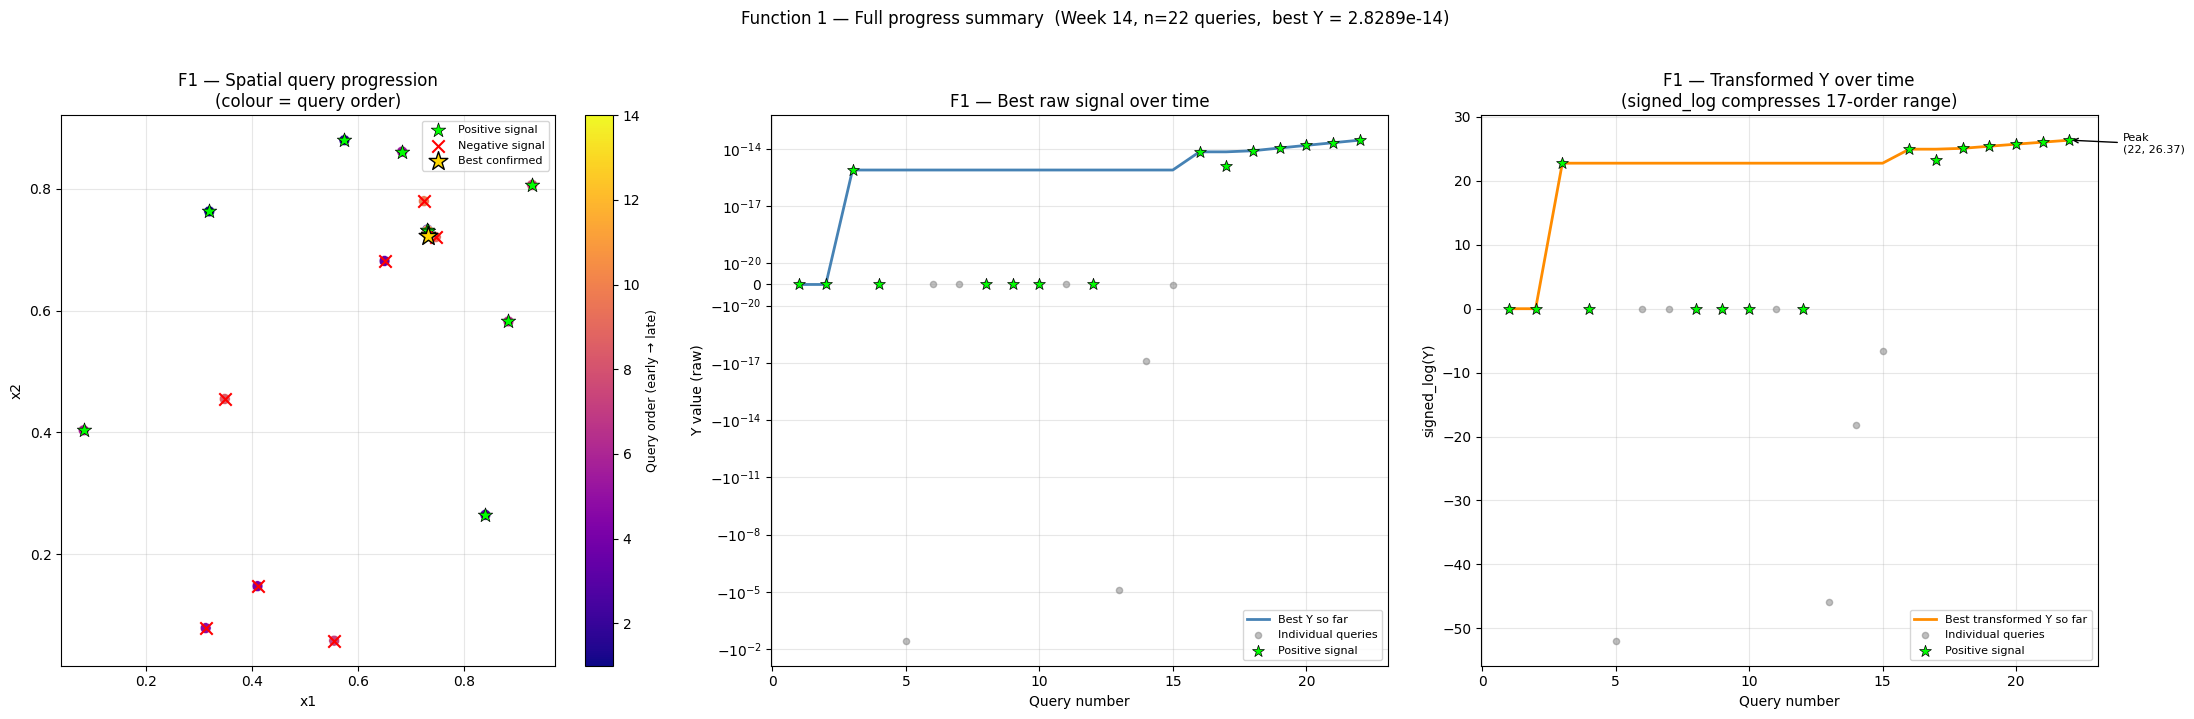

In [16]:
# =====================================================
# PROGRESS PLOT — Query progression over time
# (3-panel: spatial / raw Y / transformed Y)
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Left plot: spatial progression coloured by query order ---
n_points = len(Y)
week_ids = np.linspace(1, current_week, n_points)

scatter = axes[0].scatter(
    X[:, 0], X[:, 1],
    c=week_ids,
    cmap='plasma',
    s=60,
    zorder=3,
    edgecolors='white',
    linewidths=0.3
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Query order (early → late)', fontsize=9)

pos_mask = Y > 0
neg_mask = Y < 0
if np.any(pos_mask):
    axes[0].scatter(X[pos_mask, 0], X[pos_mask, 1],
                    c='lime', s=120, marker='*',
                    zorder=5, edgecolors='black',
                    linewidths=0.5, label='Positive signal')
if np.any(neg_mask):
    axes[0].scatter(X[neg_mask, 0], X[neg_mask, 1],
                    c='red', s=80, marker='x',
                    zorder=5, label='Negative signal')

axes[0].scatter(*best_signal, c='gold', s=200,
                marker='*', zorder=6,
                edgecolors='black', label='Best confirmed')

axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("F1 — Spatial query progression\n(colour = query order)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Middle plot: best raw Y over time ---
best_so_far = np.maximum.accumulate(Y)
query_nums  = range(1, n_points + 1)

axes[1].plot(query_nums, best_so_far,
             color='steelblue', linewidth=2,
             label='Best Y so far')
axes[1].scatter(query_nums, Y,
                c='gray', s=20, alpha=0.5,
                zorder=3, label='Individual queries')

pos_indices = np.where(pos_mask)[0]
if len(pos_indices) > 0:
    axes[1].scatter(pos_indices + 1, Y[pos_indices],
                    c='lime', s=80, marker='*',
                    zorder=5, edgecolors='black',
                    linewidths=0.5, label='Positive signal')

axes[1].set_xlabel("Query number")
axes[1].set_ylabel("Y value (raw)")
axes[1].set_title("F1 — Best raw signal over time")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('symlog', linthresh=1e-20)

# --- Right plot: transformed Y progression ---
Y_transformed = signed_log(Y)
best_transformed_so_far = np.maximum.accumulate(Y_transformed)

axes[2].plot(query_nums, best_transformed_so_far,
             color='darkorange', linewidth=2,
             label='Best transformed Y so far')
axes[2].scatter(query_nums, Y_transformed,
                c='gray', s=20, alpha=0.5,
                zorder=3, label='Individual queries')

if len(pos_indices) > 0:
    axes[2].scatter(pos_indices + 1, Y_transformed[pos_indices],
                    c='lime', s=80, marker='*',
                    zorder=5, edgecolors='black',
                    linewidths=0.5, label='Positive signal')

# Annotate the best transformed point
best_t_idx = np.argmax(Y_transformed)
axes[2].annotate(
    f"Peak\n({best_t_idx + 1}, {Y_transformed[best_t_idx]:.2f})",
    xy=(best_t_idx + 1, Y_transformed[best_t_idx]),
    xytext=(best_t_idx + 3, Y_transformed[best_t_idx] - 2),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=8
)

axes[2].set_xlabel("Query number")
axes[2].set_ylabel("signed_log(Y)")
axes[2].set_title("F1 — Transformed Y over time\n"
                  "(signed_log compresses 17-order range)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# --- Shared title ---
plt.suptitle(
    f"Function 1 — Full progress summary  "
    f"(Week {current_week}, n={n_points} queries,  "
    f"best Y = {np.max(Y):.4e})",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()